### Install new libraries

In [1]:
#!pip install ddgs trafilatura
#%pip install openai-agents


### Setup

In [38]:
import os
from dotenv import load_dotenv
import json
from pprint import pprint
from IPython.display import Image, display, Markdown
from ddgs import DDGS
import trafilatura

from agents import Agent, Runner, function_tool
from agents.extensions.handoff_prompt import RECOMMENDED_PROMPT_PREFIX


# ------------------------------
# Setup
# ------------------------------

load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if OPENAI_API_KEY is None:
	raise Exception("API key is missing")

MODEL = "gpt-4.1-mini"


### Step 1: Define the Tools

In [39]:
@function_tool
def search_web(query: str):
	"""Search the web using DuckDuckGo browser. Returns 3 results."""
	ddgs = DDGS()
	results = ddgs.text(query, max_results=3)
	print(f"  \u2705 search_web: Got results for {query}")
	return json.dumps(results, indent=2)

In [40]:
@function_tool
def fetch_url(url: str):
	"""Fetch the content of a URL using trafilatura."""
	downloaded = trafilatura.fetch_url(url)
	if downloaded:
		text =  trafilatura.extract(downloaded)
		if text:
			truncated_text = text[:2000]  # Truncate to 2,000 characters
			print(f"  \u2705 fetch_url: Got text: {len(text)} chars from {url[:60]}")
			return truncated_text
	print(f"  \u274C Failed to fetch or extract text.") # For debugging
	return f"Could not extract text from {url}. Try a different source." # For LLM input feedback


### Step 2: Describe as LLM tools

In [41]:
tools = []

In [42]:
import base64
import urllib.request
from openai import OpenAI

openai_client = OpenAI()

@function_tool
def generate_image(prompt: str) -> str:
	"""Generate an image using gpt-image-1-mini and save it to a local file."""
	print(f"  🎨 generate_image prompt: {prompt[:80]}...")
	try:
		response = openai_client.images.generate(
			model="gpt-image-1-mini",
			prompt=prompt,
			size="1024x1024",
			quality="high",
			n=1
		)

		item = response.data[0]
		filename = "hero_image.png"

		# 1. Handle b64_json (Decode bytes and save locally)
		if getattr(item, "b64_json", None) and item.b64_json:
			with open(filename, "wb") as f:
				f.write(base64.b64decode(item.b64_json))
			print(f"  ✅ generate_image: Saved to {filename}")
			return f"Image generated successfully and saved locally as: {filename}"

		# 2. Handle HTTP URL (Download and save locally)
		if getattr(item, "url", None) and item.url:
			urllib.request.urlretrieve(item.url, filename)
			print(f"  ✅ generate_image: Saved to {filename}")
			return f"Image generated successfully and saved locally as: {filename}"

		return "Failed to generate image: API returned empty data."

	except Exception as e:
		print(f"  ❌ generate_image failed: {e}")
		return f"Failed to generate image: {e}"

### Step 2: The Agents

 This Agent Prompts tells the LLM who it is and how to behave. The key things:
- What its job is
- What tools it has
- What process to follow
- What output format to produce




#### Research Agent

In [43]:

RESEARCH_AGENT_PROMPT = """You are a research specialist. Your job is to research a given topic
and produce a comprehensive research brief.

You have access to two tools:
- search_web: Search the web for information
- fetch_url: Fetch and read the full content of a web page

***IMPORTANT:
After each search with search_web, you MUST first explain your reasoning:
- Which URLs look most relevant and why
- Which ones you will fetch and why
- Which ones you are skipping and why
Only AFTER writing out your reasoning should you call fetch_url.
***

Your typical process:
1. Search for the topic to find relevant sources
2. Reflect on the search results — which sources look most relevant and why?
3. Fetch the full content of the 2-3 best URLs
4. Reflect on what you have gathered. Do you have enough? Are there gaps?
5. If there are gaps, search again with a different query
6. When you have enough information from at least 3 different sources, synthesize into a research brief

You MUST gather information from at least 3 distinct sources before delivering your brief.
If you have fewer than 3 sources, keep searching.

Your research brief MUST include:
- Key facts and statistics
- Main themes and arguments from the sources
- Notable data points
- Source URLs for attribution

Until you are ready, just keep working — search, fetch, think, reflect.
Do not rush. Take time to reflect between tool calls before deciding your next step.
Not every response needs a tool call — sometimes just thinking through what you have is the right move."""

research_agent = Agent(
	name="Research Agent",
	instructions=RESEARCH_AGENT_PROMPT,
	model=MODEL,
	tools=[search_web, fetch_url]
)


#### Image Generator Agent

In [50]:
IMAGE_AGENT_PROMPT = """You are an image prompt specialist. Given a topic and content summary,
craft a detailed gpt-image-1-mini prompt for a hero image.

Call generate_image exactly ONCE with your prompt. One image only.

IMPORTANT: Return ONLY the exact filename returned by generate_image in markdown format, like: ![hero image](hero_image.png). Do NOT add prefixes like 'sandbox:/'.

Rules for your gpt-image-1-mini prompt:
- Describe a clean, abstract, futuristic concept representing innovation and technology (e.g., glowing network nodes, futuristic digital interfaces, conceptual blue light, subtle molecular structures).
- avoid triggering image safety filters.
- No text, logos, or words in the image.
- Focus on lighting, composition, futuristic mood, and abstract aesthetics.
- Focus on a single compelling visual concept that captures the theme.
- Keep the prompt under 200 words.

Call generate_image exactly ONCE with your prompt. One image only.

IMPORTANT: When returning the image URL, copy it EXACTLY character by character. Do not modify, shorten, or paraphrase the URL.
"""


image_agent = Agent(
	name="Image Agent",
	instructions=IMAGE_AGENT_PROMPT,
	model=MODEL,
	tools=[generate_image]
)

image_agent_as_tool = image_agent.as_tool(
	tool_name="image_agent",
	tool_description="Generate a hero image for an article based on a topic and content summary. Supply the topic and content summary."
)

### Orchestrator Agent

In [45]:
ORCHESTRATOR_AGENT_PROMPT = RECOMMENDED_PROMPT_PREFIX + """You are the orchestrator of a multi-agent article writing system.
Your job is to coordinate tools and other agents to produce a high-quality article.
Use the tools available to you and/or delegate tasks to the appropriate agents.
Never do the work yourself. Always use tools or agents.
Your tools and agents are specialists and should be doing the work, you are the manager.

Deliver the selected research brief as the final output, and
include the image at the top of your final output in markdown format strictly as: ![hero image](hero_image.png)

CRITICAL: Do not add any path prefixes like 'sandbox:/' or folder names. Use 'hero_image.png' as the exact relative filename.

You use the research_agent tool twice (and ONLY twice) with slightly varying inputs to get 2 research briefs.
You pick the best research brief out of the two and deliver it as output.
Do not combine the two briefs, just pick the best one.
Do not do the research yourself or add anything, you MUST use the research_agent tool to get the briefs.

Once you have selected the best brief, you MUST use the image_agent tool to generate an image.
Use the research brief to supply the image agent with the topic and content summary it needs to generate the image.

Handoff the research brief to the Journalist Writer Agent, and
include the image URL as part of your handoff.

IMPORTANT: When passing the image URL, copy it EXACTLY character by character. Do not modify, shorten, or paraphrase the URL.
"""

orchestrator_agent = Agent(
	name="Orchestrator Agent",
	model="o4-mini", ##Reasoning
	instructions=ORCHESTRATOR_AGENT_PROMPT,
	tools=[research_agent.as_tool(tool_name="research_agent", tool_description="Research a topic and return a brief with key facts, statistics, themes,  and source URLs. Pass the topic as input.", max_turns=25),
		image_agent_as_tool]
)

#### Writer Agent A: The Journalist

In [46]:
JOURNALIST_WRITER_PROMPT = RECOMMENDED_PROMPT_PREFIX + """You are an investigative journalist.
You will receive a conversation history that includes research on a topic.

Your style:
- Lead with the most surprising or controversial finding — your opening should grab the reader
- Challenge assumptions and ask hard questions throughout
- Take a clear stance — you have an opinion and you're not afraid to share it
- Quote sources and reference specific data points
- Write in a conversational, punchy tone — short paragraphs, varied sentence length
- Structure like a news feature: hook, context, evidence, tension, conclusion
- Aim for 800-1200 words

Do NOT use generic section headers like "Introduction", "Conclusion", or "Overview". Use creative, specific headers that grab attention.
Do NOT overuse headers. Only use one title and BETWEEN 2 and 3 headers in total for the entire article.
Do NOT use bullet points or numbered lists. Write in full sentences and paragraphs.
Do NOT ask for feedback, offer revisions, or include any commentary after the article.
Just deliver the finished article in markdown format. """

journalist_agent = Agent(
	name="Journalist Agent",
	instructions=JOURNALIST_WRITER_PROMPT,
	model=MODEL
)

#### Update the Orchestrator Agent

In [47]:
from agents import handoff

orchestrator_agent.handoffs = [journalist_agent]

In [ ]:
# from agents import trace

# with trace("Journalist test", group_id="Learning AI Engineering"):
#     result = await Runner.run(
#         journalist_agent,
#         input="Write an article about the following topic: Zebra migration patterns in Africa",
#         max_turns=30
# 	)

#### Test Running the Journalist Agent

In [ ]:
# print(f"Agent: {result.last_agent.name}")
# print(f"----")
# display(Markdown(result.final_output))

### Let's Run IT!

In [48]:
from agents import trace

with trace("Article Writer with Handoff", group_id="Learning AI Engineering"):
	result = await Runner.run(
		orchestrator_agent,
		input="Research the following topic and produce a comprehensive research brief: How will AI is used in healthcare 2040?",
		#input="Research the following topic and produce a comprehensive research brief: How seniors can understand AI",
		#input="Research the following topic and produce a comprehensive research brief: How to become an AI engineer",
		#input="Research the following topic and produce a comprehensive research brief: How to start a side gig as an AI engineer",
		max_turns=30
	)

  ✅ search_web: Got results for AI in healthcare 2040 technological advancements patient outcomes ethical considerations
  ❌ Failed to fetch or extract text.
  ❌ Failed to fetch or extract text.
  ❌ Failed to fetch or extract text.
  ✅ search_web: Got results for future of AI in healthcare by 2040
  ✅ search_web: Got results for ethical considerations AI healthcare future
  ❌ Failed to fetch or extract text.
  ❌ Failed to fetch or extract text.
  ✅ fetch_url: Got text: 36035 chars from https://www.cdc.gov/pcd/issues/2024/24_0245.htm
  ✅ search_web: Got results for AI technological advancements in healthcare by 2040 patient outcomes statistics
  ❌ Failed to fetch or extract text.
  ❌ Failed to fetch or extract text.
  ✅ search_web: Got results for AI healthcare future projections 2040 patient outcomes technological advancements statistics report
  ❌ Failed to fetch or extract text.
  ✅ search_web: Got results for AI impact on patient outcomes healthcare 2040
  ❌ Failed to fetch or extra

Agent: Journalist Agent
---



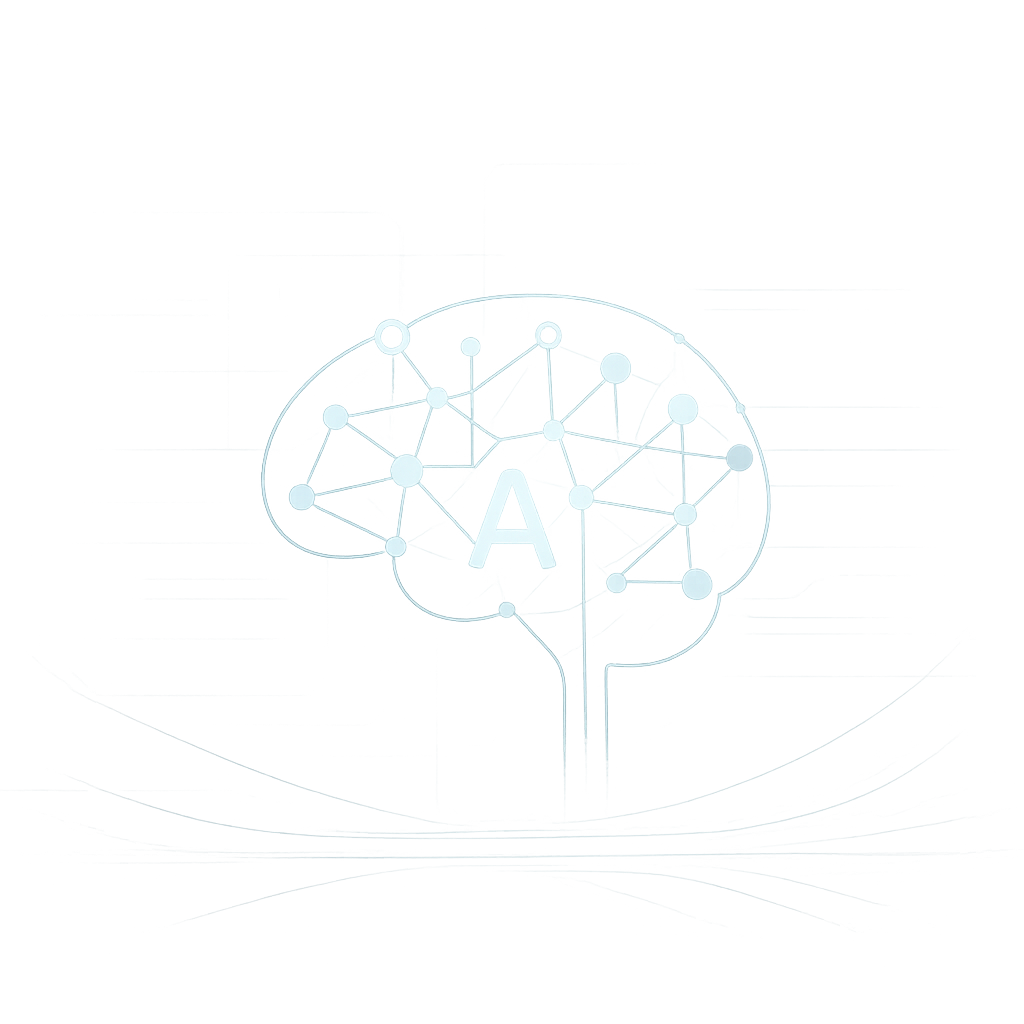

# The AI Revolution in Healthcare: What 2040 Has in Store

Picture this: a healthcare system where diseases are detected before symptoms even appear, surgeries are flawlessly executed by robotic hands guided by real-time AI, and treatment plans are perfectly tailored to your unique genetic and lifestyle profile. This isn’t science fiction—it’s the future of healthcare by 2040, powered by artificial intelligence.

## Diagnostics, Treatment, and Care — Supercharged

AI’s impact on healthcare is already tangible today, with algorithms assisting radiologists, chatbots conducting initial patient triage, and predictive models managing chronic diseases. But by 2040? The transformation will be orders of magnitude greater.

Imagine AI systems equipped with superhuman diagnostic abilities. They will analyze complex medical data from genomics, imaging, and wearables, providing near-instant and ultra-precise diagnoses. According to recent forecasts, AI-driven diagnostics will reduce errors that currently plague healthcare, where misdiagnosis affects an estimated 12 million adults annually in the U.S. alone. The ability to parse huge datasets identifies subtle patterns beyond any human physician’s reach—catching cancers earlier, recognizing rare diseases faster, and personalizing care in ways once unimaginable.

On the treatment front, personalized medicine will become the norm. AI will harness your DNA, lifestyle data, and past medical history to design therapies tailored specifically for you. Such precision promises to boost therapeutic effectiveness while slashing unwanted side effects—a monumental leap from the trial-and-error approach dragging medicine today.

Robotic surgery will be another AI-highlighted frontier. Surgeons armed with AI augmentation won’t just rely on steady hands; real-time AI input will guide incisions with micrometer precision and adapt procedures mid-operation based on live physiological feedback. Ultimately, surgeries will become safer, less invasive, and deliver faster recoveries.

Beyond clinical care, AI-powered systems will streamline administrative tasks, from scheduling to billing, freeing healthcare workers to focus on patient interaction. Predictive analytics will optimize staffing, manage resource allocation, and anticipate patient surges—a true revolution in healthcare management.

## Ethics and Equity: The Double-Edged Sword

Of course, this AI utopia raises serious questions. One of the starkest challenges is bias. AI models learn from existing data typically sourced from majority populations or wealthier regions, inherently risking embedding and amplifying disparities. Left unchecked, AI could worsen health inequities by providing poorer outcomes for marginalized groups.

Transparency in AI decision-making will be paramount. The so-called “black box” models—complex AI systems whose decision logic is opaque—even to their creators—pose risks to patient trust and legal accountability. Patients and clinicians alike will demand interpretable, explainable AI to make informed decisions together.

Privacy and data security concerns also loom large. AI’s hunger for vast health datasets conflicts with the imperative to protect sensitive patient information. By 2040, robust regulations and innovative data governance frameworks must evolve to safeguard these digital assets without stifling innovation.

Finally, universal access to AI-powered healthcare cannot be assumed. Without deliberate policy and global cooperation, AI tools may deepen the divide between wealthy and resource-poor regions, reinforcing structural inequities in healthcare availability and quality across the world.

The Centers for Disease Control and Prevention (CDC) emphasize these concerns, advocating for inclusive data strategies and ethical governance models to ensure AI’s benefits uplift all populations, not just the privileged few.

## What Must We Do Now?

Forecasts for AI in healthcare by 2040 are thrilling, but they are not automatic. They require intentional design, vigilant regulation, and a steadfast commitment to equity and ethics.

Will the healthcare sector embrace AI as a tool to democratize access and improve outcomes? Or will it succumb to the allure of convenience and efficiency at the expense of patient rights and social justice?

The answer hinges on the decisions we make today about AI development, deployment, and governance.

In short, AI promises to revolutionize healthcare by 2040 with unparalleled precision, personalization, and efficiency. Yet we cannot afford blind faith. Scrutiny, oversight, and inclusion must guide this transformation—otherwise, the future of medicine could widen, not bridge, the health divides plaguing our world.

---

Sources and Further Reading:

- Centers for Disease Control and Prevention (CDC) commentary on AI ethics and health equity: https://www.cdc.gov/
- Statista insights on AI adoption in healthcare trends and projections: https://www.statista.com/topics/6742/artificial-intelligence-in-healthcare/
- Various scientific abstracts discussing regulatory frameworks and data privacy challenges in AI healthcare at 2040 horizon.

![AI in Healthcare 2040](hero_image.png)

In [49]:
import base64
from IPython.display import Markdown, display, HTML

print(f"Agent: {result.last_agent.name}")
print("---")

# Read local image bytes and encode to base64 data URI (bypasses browser caching)
with open("hero_image.png", "rb") as f:
    img_b64 = base64.b64encode(f.read()).decode("utf-8")
img_html = f'<img src="data:image/png;base64,{img_b64}" alt="Hero Image"/>'

# Build cleaned markdown without the markdown image reference
clean_output = result.final_output.replace("sandbox:/", "")
clean_output_no_image = clean_output.replace("![hero image](hero_image.png)", "")

# Display the embedded image (HTML) and then the markdown content
display(HTML(img_html))
display(Markdown(clean_output_no_image))

In [12]:
# from IPython.display import Image, display
# import time

# print(f"Agent: {result.last_agent.name}")
# print(f"---")


# ####

# # Forces display to reload from disk rather than browser cache
# display(Image(filename='hero_image.png', data=open('hero_image.png', 'rb').read()))
# clean_output = result.final_output.replace("sandbox:/", "")
# display(Markdown(clean_output))


#### Test to generate an image of an apple and display it here in this notebook

In [13]:
# import base64
# import logging
# import os
# import sys
# from dotenv import load_dotenv
# from IPython.display import Image, display
# from openai import OpenAI

# # 1. Configure logging to stdout so step-by-step progress appears in the cell
# logging.basicConfig(
# 	level=logging.INFO,
# 	format="%(asctime)s [%(levelname)s] %(message)s",
# 	handlers=[logging.StreamHandler(sys.stdout)],
# 	force=True,  # Overrides any existing notebook logger configuration
# )
# logger = logging.getLogger("ImageTest")

# # 2. Setup API key and OpenAI client
# load_dotenv()
# api_key = os.getenv("OPENAI_API_KEY")

# if not api_key:
# 	logger.error("OPENAI_API_KEY is missing! Please check your .env file.")
# else:
# 	logger.info("Initializing OpenAI client...")
# 	client = OpenAI(api_key=api_key)

# 	# 3. Define test prompt
# 	prompt = "A simple, crisp red apple on a plain white background"
# 	logger.info(f"Sending image generation request for prompt: '{prompt}'")

# 	try:
# 		# Call the live image generation API
# 		response = client.images.generate(
# 			model="gpt-image-1-mini",
# 			prompt=prompt,
# 			size="1024x1024",
# 			quality="high",
# 			n=1,
# 		)

# 		logger.info("Received response from OpenAI API.")
# 		item = response.data[0]
# 		image_uri = None

# 		# Check if an HTTP URL was returned
# 		if getattr(item, "url", None):
# 			image_uri = item.url
# 			logger.info("  ✅ Image URL retrieved successfully!")
# 			print(f"\n--- GENERATED IMAGE URL ---\n{image_uri}\n----------------------------\n")

# 		# Check if b64_json payload was returned instead
# 		elif getattr(item, "b64_json", None):
# 			image_uri = f"data:image/png;base64,{item.b64_json}"
# 			logger.info("  ✅ Image Base64 payload retrieved successfully!")
# 			print(f"\n--- GENERATED IMAGE BASE64 DATA URI ---\n{image_uri[:100]}... (truncated)\n---------------------------------------\n")

# 		else:
# 			logger.warning("Response payload contained neither 'url' nor 'b64_json'.")

# 		# 4. Render image directly in the notebook output
# 		if image_uri:
# 			logger.info("Rendering image in notebook output...")
# 			display(Image(url=image_uri))
# 			logger.info("Image displayed successfully.")

# 	except Exception as e:
# 		logger.error(f"Image generation failed with error: {e}", exc_info=True)

In [14]:
# import base64
# import logging
# import os
# import sys
# from dotenv import load_dotenv
# from IPython.display import Image, display
# from openai import OpenAI

# # 1. Configure logging to stdout so step-by-step progress appears in the cell
# logging.basicConfig(
# 	level=logging.INFO,
# 	format="%(asctime)s [%(levelname)s] %(message)s",
# 	handlers=[logging.StreamHandler(sys.stdout)],
# 	force=True,  # Overrides any existing notebook logger configuration
# )
# logger = logging.getLogger("ImageTest")

# # 2. Setup API key and OpenAI client
# load_dotenv()
# api_key = os.getenv("OPENAI_API_KEY")

# if not api_key:
# 	logger.error("OPENAI_API_KEY is missing! Please check your .env file.")
# else:
# 	logger.info("Initializing OpenAI client...")
# 	client = OpenAI(api_key=api_key)

# 	# 3. Define the futuristic healthcare prompt
# 	prompt = (
# 		"A clean, abstract, high-tech healthcare environment in 2040. "
# 		"Futuristic medical diagnostics interface, glowing digital data visualization, "
# 		"subtle holographic human body scan, blue and teal ambient lighting, "
# 		"sleek futuristic clinical aesthetic, soft depth of field."
# 	)
# 	logger.info(f"Sending image generation request for prompt: '{prompt[:80]}...'")

# 	try:
# 		# Call the live image generation API
# 		response = client.images.generate(
# 			model="gpt-image-1-mini",
# 			prompt=prompt,
# 			size="1024x1024",
# 			quality="high",
# 			n=1,
# 		)

# 		logger.info("Received response from OpenAI API.")
# 		item = response.data[0]
# 		image_uri = None

# 		# Check if Base64 payload was returned
# 		if getattr(item, "b64_json", None):
# 			image_uri = f"data:image/png;base64,{item.b64_json}"
# 			logger.info("  ✅ Base64 payload retrieved successfully!")
# 			print(f"\n--- GENERATED IMAGE DATA URI ---\n{image_uri[:100]}... (truncated)\n---------------------------------\n")

# 		# Fallback to HTTP URL if returned
# 		elif getattr(item, "url", None):
# 			image_uri = item.url
# 			logger.info("  ✅ Image URL retrieved successfully!")
# 			print(f"\n--- GENERATED IMAGE URL ---\n{image_uri}\n----------------------------\n")

# 		else:
# 			logger.warning("Response payload contained neither 'b64_json' nor 'url'.")

# 		# 4. Render image directly in the notebook output
# 		if image_uri:
# 			logger.info("Rendering image in notebook output...")
# 			display(Image(url=image_uri))
# 			logger.info("Image displayed successfully.")

# 	except Exception as e:
# 		logger.error(f"Image generation failed with error: {e}", exc_info=True)

In [15]:
# # Diagnostic: check notebook kernel working directory and display hero_image.png
# import os
# from pathlib import Path
# from IPython.display import Image, display
# print('Kernel cwd:', os.getcwd())
# p = Path('hero_image.png')
# print('Resolved path:', p.resolve())
# print('Exists:', p.exists())
# if p.exists():
#     display(Image(filename=str(p)))
# else:
#     print('hero_image.png not found in cwd; try using absolute path or move the file into the notebook folder.')
